In [1]:
#imports 
import sys

import numpy as np
import matplotlib.pyplot as plt
import h5py

from scipy.signal import correlate, find_peaks
import pandas as pd
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import KFold
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.model_selection import KFold
from sklearn import svm
from scipy.signal import resample
from scipy.ndimage import uniform_filter1d
from sklearn.svm import OneClassSVM
import torch
import torch.nn as nn
import pywt
import importlib, pipeline_functions
importlib.reload(pipeline_functions)
from pipeline_functions import *
path = r"C:\spike-denoising-synthetic\data\real"
sample_frequency = 30000 

In [2]:
#steup
path = "C:/spike-denoising-synthetic/data/real"
sample_frequency = 30000

#load TTLs and set window_start
ttls = np.fromfile(path + "/TTLs_2.bin", dtype='<f8')
window_start = ttls[900]
print("window_start:", window_start)
print("TTLs loaded:", len(ttls))

window_start: 3602.6708
TTLs loaded: 2310


In [3]:
path = "C:/spike-denoising-synthetic/data/real"
with h5py.File(path + "/grouped_unit_1.mat", "r") as f:
    for ch in ['CH3', 'CH9', 'CH10', 'CH14', 'CH19', 'CH25', 'CH30']:
        if ch in f:
            n = len(f[ch]["aligned_zc_locs"][:].flatten())
            print(f"{ch}: {n} annotations")
        else:
            print(f"{ch}: not present")

CH3: 705 annotations
CH9: 1628 annotations
CH10: 394 annotations
CH14: 1639 annotations
CH19: 1623 annotations
CH25: 1777 annotations
CH30: 1414 annotations


In [4]:
signal_19, annotations_19, window_end = load_channel(19, path, window_start, window_seconds=1800)
print("ch19 (30 min) samples:", len(signal_19))
print("ch19 (30 min) annotations:", len(annotations_19))
print("window_end:", window_end)

ch19 (30 min) samples: 54000000
ch19 (30 min) annotations: 647
window_end: 5402.6708


In [5]:
#check drift in 30 mins
early_spikes = annotations_19[annotations_19 < window_start + 900]# first 15 min
late_spikes = annotations_19[annotations_19 >= window_start + 900]# last 15 min
early_template = build_template_from_annotations(signal_19, early_spikes, window_start)
late_template = build_template_from_annotations(signal_19, late_spikes, window_start)
corr = np.corrcoef(early_template, late_template)[0, 1]
print(f"early spikes: {len(early_spikes)}, late spikes: {len(late_spikes)}")
print(f"early template trough: {early_template.min():.2f}, late template trough: {late_template.min():.2f}")
print(f"correlation between early and late templates: {corr:.3f}")

early spikes: 177, late spikes: 470
early template trough: -11.01, late template trough: -11.07
correlation between early and late templates: 0.980


In [99]:
def run_channel_pipeline(channel_number, path, window_start, ttls, window_seconds=1800, eval_fraction=0.3, sample_frequency=30000, n_boot=2000):
    """
    run full leakage safe single channel pipeline for one channel. return reustls
    """
    print(f"\n{'='*50}\nCHANNEL {channel_number}\n{'='*50}")
    #load
    signal, annotations, window_end = load_channel(channel_number, path, window_start, window_seconds)
    print(f"loaded: {len(signal)} samples, {len(annotations)} annotations")

    # chronological split
    split_time = window_start + (window_end - window_start) * (1 - eval_fraction)
    ground_truth_dev = annotations[annotations < split_time]
    ground_truth_eval = annotations[annotations >= split_time]
    ttls_window = ttls[(ttls >= window_start) & (ttls <= window_end)]
    ttls_dev = ttls_window[ttls_window < split_time]
    print(f"split: dev {len(ground_truth_dev)} targets, eval {len(ground_truth_eval)} targets")

    #latency on dev
    lat_dev = post_stimulus_latencies(ground_truth_dev, ttls_dev)
    median_lat_dev = float(np.median(lat_dev))
    #dev raw template
    raw_template_dev = build_template_from_annotations(signal, ground_truth_dev, window_start)

    #train denoisers on dev template
    noisy, clean = make_training_pairs_real(raw_template_dev)
    mse = nn.MSELoss()
    #dense
    torch.manual_seed(0)
    dense = DenseDAE(); opt = torch.optim.Adam(dense.parameters(), lr=1e-3)
    dense_batches = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(noisy, clean), batch_size=256, shuffle=True)
    for _ in range(30):
        for noisy_batch, clean_batch in dense_batches:
            opt.zero_grad(); loss = mse(dense(noisy_batch), clean_batch); loss.backward(); opt.step()
    #conv
    torch.manual_seed(0)
    conv = ConvDAE(); opt = torch.optim.Adam(conv.parameters(), lr=1e-3)
    noisy_conv, clean_conv = noisy.unsqueeze(1), clean.unsqueeze(1)
    conv_batches = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(noisy_conv, clean_conv), batch_size=256, shuffle=True)
    for _ in range(30):
        for noisy_batch, clean_batch in conv_batches:
            opt.zero_grad(); loss = mse(conv(noisy_batch), clean_batch); loss.backward(); opt.step()
            
    print("denoisers trained")
    #apply denoisers
    signal_wavelet = denoise_swt_channel(signal)
    signal_dense = ae_denoise_signal(signal, dense)
    signal_conv = conv_ae_denoise(signal, conv)
    signals = {"raw": signal, "wavelet": signal_wavelet, "dense": signal_dense, "conv": signal_conv}
    print("denoisers applied")
    #denoising quality, MAD and peak-to-peak aplitude 
    denoising_quality = {}
    raw_ptp = None
    for name, signal in signals.items():
        mad = np.median(np.abs(signal)) / 0.6745
        amplitudes = []
        for spike_time in ground_truth_dev:
            centre_index = int(round((spike_time - window_start) * sample_frequency))
            segment = signal[centre_index-45:centre_index+45]
            if len(segment) == 90:
                amplitudes.append(segment.max() - segment.min())
        ptp = np.mean(amplitudes)
        if name == "raw":
            raw_ptp = ptp
        denoising_quality[name] = {"mad": mad, "ptp": ptp}
    for name in denoising_quality:
        denoising_quality[name]["retained"] = denoising_quality[name]["ptp"] / raw_ptp

    
    # build dev templates for each signal
    templates_dev = {name: build_template_from_annotations(signal, ground_truth_dev, window_start)
                     for name, signal in signals.items()}

    # select detection parameters on dev (sweep shape threshold and latency half-width)
    best_f1, best_params = 0, None
    scores_raw = template_match(signals["raw"], templates_dev["raw"])
    for shape_th in [0.2, 0.3, 0.4, 0.5]:
        for lat_half_width in [2, 3, 4, 5, 6]:
            peaks, _ = find_peaks(scores_raw, height=shape_th, distance=90)
            detections = peaks / sample_frequency + window_start
            lo = (median_lat_dev - lat_half_width) / 1000
            hi = (median_lat_dev + lat_half_width) / 1000
            in_window = detections[in_latency_window(detections, ttls, lat_min=lo, lat_max=hi)]
            dev_det = in_window[in_window < split_time]
            _, _, _, _, _, f1, _ = score_detections_counts(dev_det, ground_truth_dev, tolerance=0.002)
            if f1 > best_f1:
                best_f1, best_params = f1, (shape_th, lat_half_width)
    shape_th, lat_half_width = best_params
    lo_window = (median_lat_dev - lat_half_width) / 1000
    hi_window = (median_lat_dev + lat_half_width) / 1000
    print(f"selected params: shape {shape_th}, latency half-width {lat_half_width} ms (dev F1 {best_f1:.3f})")

    #detect on dev and eval (all signals), with frozen parameters
    dev_detections = {}; eval_detections = {}
    for name, signal in signals.items():
        scores = template_match(signal, templates_dev[name])
        peaks, _ = find_peaks(scores, height=shape_th, distance=90)
        detections = peaks / sample_frequency + window_start
        in_window = detections[in_latency_window(detections, ttls, lat_min=lo_window, lat_max=hi_window)]
        dev_detections[name] = in_window[in_window < split_time]
        eval_detections[name] = in_window[in_window >= split_time]

    #detection metrics on held out eval for per signal
    detection_metrics ={}
    for name in signals:
        tp, fp, fn, precision, recall, f1, fptp = score_detections_counts(eval_detections[name], ground_truth_eval, tolerance=0.002)
        detection_metrics[name] = {"survivors": len(eval_detections[name]), "tp": tp, "fp": fp, "fn": fn, "precision": precision, "recall": recall, "f1": f1, "fptp": fptp}

    #label survivors
    dev_labels = {name: label_survivors(dev_detections[name], ground_truth_dev) for name in signals}
    eval_labels = {name: label_survivors(eval_detections[name], ground_truth_eval) for name in signals}

    # classify (2x2, fit dev, score eval, stratified CIs)
    def make_arms(denoiser):
        return [("Full raw", "raw", "raw"), ("Full denoised", denoiser, denoiser),
                ("Hybrid A", denoiser, "raw"), ("Hybrid B", "raw", denoiser)]
    results = {}
    for classifier in ["oneclass", "twoclass"]:
        for denoiser in ["wavelet", "dense", "conv"]:
            for arm_label, detection_signal, cutout_signal in make_arms(denoiser):
                dev_waveforms, dev_keep = extract_waveforms(dev_detections[detection_signal], signals[cutout_signal], window_start)
                eval_waveforms, eval_keep = extract_waveforms(eval_detections[detection_signal], signals[cutout_signal], window_start)
                dev_lab = dev_labels[detection_signal][dev_keep]
                eval_lab = eval_labels[detection_signal][eval_keep]
                if classifier == "oneclass":
                    labels, scores, predictions = oneclass_dev_eval(dev_waveforms, dev_lab, eval_waveforms, eval_lab)
                else:
                    labels, scores, predictions = twoclass_dev_eval(dev_waveforms, dev_lab, eval_waveforms, eval_lab)
                ci = bootstrap_ci_stratified(labels, scores, predictions, n_boot=n_boot)
                #classification metrics from predictions
                clas_tp = int(((predictions == 1) & (labels == 1)).sum())
                clas_fp = int(((predictions == 1) & (labels == 0)).sum())
                clas_fn = int(((predictions == 0) & (labels == 1)).sum())
                clas_tn = int(((predictions == 0) & (labels == 0)).sum())
                clas_precision = clas_tp / (clas_tp + clas_fp) if (clas_tp + clas_fp) else 0.0
                clas_recall = clas_tp / (clas_tp + clas_fn) if (clas_tp + clas_fn) else 0.0
                clas_f1 = 2*clas_precision*clas_recall/(clas_precision+clas_recall) if (clas_precision+clas_recall) else 0.0
                results[(classifier, denoiser, arm_label)] = {"roc_auc": ci["roc_auc"], "pr_ap": ci["pr_ap"], "base": eval_lab.mean(), "tp": clas_tp, "fp": clas_fp, "fn": clas_fn, "tn": clas_tn,
                                                              "precision": clas_precision, "recall": clas_recall, "f1": clas_f1}
    print("classification done")
    return {"channel": channel_number, "dev_targets": len(ground_truth_dev), "eval_targets": len(ground_truth_eval), "params": best_params,"classification": results, "detection": detection_metrics, "denoising_quality": denoising_quality}

In [100]:
all_results = {}
for ch in [9, 14, 19, 25, 30]:
    all_results[ch] = run_channel_pipeline(ch, path, window_start, ttls, window_seconds=900)


CHANNEL 9
loaded: 27000000 samples, 170 annotations
split: dev 108 targets, eval 62 targets
denoisers trained
denoisers applied
selected params: shape 0.2, latency half-width 2 ms (dev F1 0.519)
classification done

CHANNEL 14
loaded: 27000000 samples, 173 annotations
split: dev 113 targets, eval 60 targets
denoisers trained
denoisers applied
selected params: shape 0.2, latency half-width 2 ms (dev F1 0.505)
classification done

CHANNEL 19
loaded: 27000000 samples, 177 annotations
split: dev 116 targets, eval 61 targets
denoisers trained
denoisers applied
selected params: shape 0.2, latency half-width 2 ms (dev F1 0.518)
classification done

CHANNEL 25
loaded: 27000000 samples, 186 annotations
split: dev 120 targets, eval 66 targets
denoisers trained
denoisers applied
selected params: shape 0.2, latency half-width 2 ms (dev F1 0.502)
classification done

CHANNEL 30
loaded: 27000000 samples, 174 annotations
split: dev 113 targets, eval 61 targets
denoisers trained
denoisers applied
sel

In [101]:
#check the new data is stored 
print("detection keys:", all_results[19]["detection"].keys())
print("denoising_quality keys:", all_results[19]["denoising_quality"].keys())
print("raw detection:", all_results[19]["detection"]["raw"])
print("raw denoising quality:", all_results[19]["denoising_quality"]["raw"])

detection keys: dict_keys(['raw', 'wavelet', 'dense', 'conv'])
denoising_quality keys: dict_keys(['raw', 'wavelet', 'dense', 'conv'])
raw detection: {'survivors': 63, 'tp': 11, 'fp': 52, 'fn': 50, 'precision': 0.1746031746031746, 'recall': 0.18032786885245902, 'f1': 0.1774193548387097, 'fptp': 4.7272727272727275}
raw denoising quality: {'mad': np.float64(4.958328650429573), 'ptp': np.float64(24.08081576864276), 'retained': np.float64(1.0)}


# Setup 

In [102]:
#setup table
print(f"{'Channel':>8s} {'Total':>7s} {'Window':>7s} {'Dev':>5s} {'Eval':>5s} {'MAD':>7s}")
for ch in [9, 14, 19, 25, 30]:
    res = all_results[ch]
    window_ann = res["dev_targets"] + res["eval_targets"]
    mad = res["denoising_quality"]["raw"]["mad"]
    # read total annotations from the file
    with h5py.File(path + "/grouped_unit_1.mat", "r") as f:
        total = len(f[f"CH{ch}"]["aligned_zc_locs"][:].flatten())
    print(f"{ch:>8d} {total:>7d} {window_ann:>7d} "
          f"{res['dev_targets']:>5d} {res['eval_targets']:>5d} {mad:>7.2f}")

 Channel   Total  Window   Dev  Eval     MAD
       9    1628     170   108    62    4.80
      14    1639     173   113    60    4.88
      19    1623     177   116    61    4.96
      25    1777     186   120    66    4.63
      30    1414     174   113    61    4.82


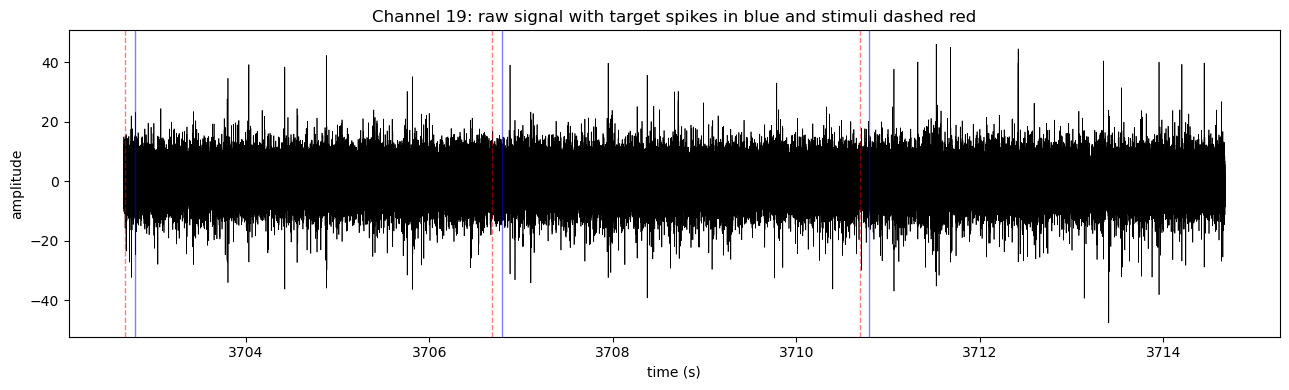

In [103]:
# setup figure: raw signal segment with spikes and stimuli marked (ch19 as example)
ch = 19
signal, annotations, window_end = load_channel(ch, path, window_start, window_seconds=900)
# short segment 
segment_start_time = window_start + 100 # 100 sec into the window
segment_duration = 12 #seconds
lo = int((segment_start_time - window_start) * sample_frequency)
hi = int((segment_start_time + segment_duration - window_start) * sample_frequency)
time = np.arange(hi - lo) / sample_frequency + segment_start_time # absolute time

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(time, signal[lo:hi], linewidth=0.5, color='black')

#mark the target spike in the segment 
spikes_in_segment = annotations[(annotations >= segment_start_time) & (annotations < segment_start_time + segment_duration)]
for spike_time in spikes_in_segment:
    ax.axvline(spike_time, color='blue', alpha=0.5, linewidth=1)

#mark the stimuli in this segemnt 
stimulus_time_in_segment = ttls[(ttls >= segment_start_time) & (ttls < segment_start_time + segment_duration)]
for spike_time in stimulus_time_in_segment:
    ax.axvline(spike_time, color='red', linestyle='--', alpha=0.5, linewidth=1)
ax.set_xlabel("time (s)")
ax.set_ylabel("amplitude")
ax.set_title(f"Channel {ch}: raw signal with target spikes in blue and stimuli dashed red")

plt.tight_layout()
plt.savefig('raw signal with target spikes in blue and stimuli dashed red.png')
plt.show()


# Detection performance across channels before denoising

In [104]:
#detection performance raw, held-out eavluation on all channel before denoiisng
print(f"{'Channel':>8s} {'Survivors':>5s} {'TP':>4s} {'FP':>4s} {'FN':4s} {'precision':>6s} {'Recall':>7s} {'F1':>6s} {'FP/TP':>6s}")
for ch in [9, 14, 19, 25, 30]:
    d = all_results[ch]["detection"]["raw"]
    print(f"{ch:>8d} {d['survivors']:>5d} {d['tp']:>4d} {d['fp']:>4d} {d['fn']:>4d} "
          f"{d['precision']:>6.3f} {d['recall']:>7.3f} {d['f1']:>6.3f} {d['fptp']:>6.2f}")

 Channel Survivors   TP   FP FN   precision  Recall     F1  FP/TP
       9    61   12   49   50  0.197   0.194  0.195   4.08
      14    60   16   44   44  0.267   0.267  0.267   2.75
      19    63   11   52   50  0.175   0.180  0.177   4.73
      25    58   14   44   52  0.241   0.212  0.226   3.14
      30    62   13   49   48  0.210   0.213  0.211   3.77


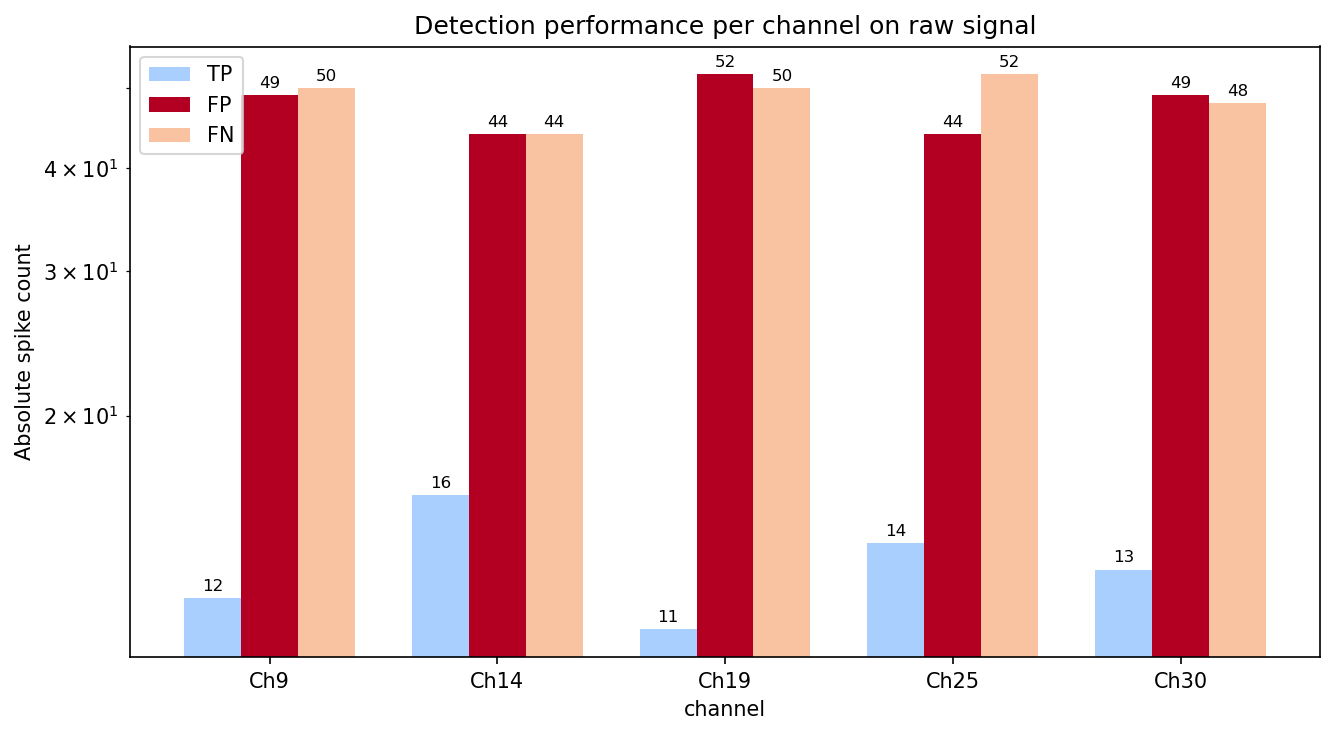

In [112]:
#bar plot 
channels= [9, 14, 19, 25, 30]
tp_vals = [all_results[ch]["detection"]["raw"]["tp"] for ch in channels]
fp_vals = [all_results[ch]["detection"]["raw"]["fp"] for ch in channels]
fn_vals = [all_results[ch]["detection"]["raw"]["fn"] for ch in channels]
x = np.arange(len(channels))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 5), dpi=150)

bars_tp = ax.bar(x - width, tp_vals, width, label='TP', color='#A9CFFF')
bars_fp = ax.bar(x, fp_vals, width, label='FP', color='#B30022')
bars_fn = ax.bar(x + width, fn_vals, width, label='FN', color='#F9C3A1')
#numbers on top of each bar
for bars in [bars_tp, bars_fp, bars_fn]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{int(height)}',
                    xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 2), textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)
ax.set_yscale('log') #log sccale follwoing troglio et al, 2026

ax.set_xticks(x)
ax.set_xticklabels([f"Ch{ch}" for ch in channels])
ax.set_ylabel("Absolute spike count")
ax.set_xlabel("channel")
ax.set_title("Detection performance per channel on raw signal")
ax.legend()
plt.tight_layout()
plt.savefig('Detection performamce befoer denoiisng.png', dpi=300, bbox_inches='tight')
plt.show()


Spike detection performance using similarity thresholding and a latency window: TP, FP, and FN are visualised on a log scale for the raw signal across the five channels on the held-out evaluation period. All channels have higher false positives compared to the true positives, with Ch19 exhibiting the most false positives and the least true positives. 


Detection was applied to each channel using the fixed parameters that was selected on the development set, and then scored once against the refernce annotations in the held out evaluation peiod. Across all five channels, the false positives to true positives ratio exceeds 1, which means that every channel produces more false positives than true positives on noisy raw signal. The recall was low (0.18 to 0.27), and precision was also around (0.18 to 0.27). 

### interpretation 
These results indicate that these false positives resemble the target spikes in both waveform and latency. These results are consistent with Troglio et al., 2026. If background noise is detected as false positives, denoising these signals would produce less false positives. 

# Calssification before denising with per channel ROC-AUC on both classifiers.

- ROC-AUC table
- Figure
- TP/FP/FN + F1/precision/recall (add later)

In [106]:
#calssification before denoising on all channels
channels = [9, 14, 19, 25, 30]
print(f"{'Channel':>8s} {'one-class ROC-AUC [95% CI]':>28s} {'two-class ROC-AUC [95% CI]':>28s}")
for ch in channels:
    oneclass = all_results[ch]["classification"][("oneclass", "wavelet", "Full raw")]
    twoclass = all_results[ch]["classification"][("twoclass", "wavelet", "Full raw")]
    oneclass_roc = oneclass["roc_auc"]; twoclass_roc = twoclass["roc_auc"]
    print(f"{ch:>8d} "
          f"{oneclass_roc[0]:.3f} [{oneclass_roc[1]:.3f}, {oneclass_roc[2]:.3f}]".rjust(28) + " " +
          f"{twoclass_roc[0]:.3f} [{twoclass_roc[1]:.3f}, {twoclass_roc[2]:.3f}]".rjust(28))

 Channel   one-class ROC-AUC [95% CI]   two-class ROC-AUC [95% CI]
       9 0.602 [0.446, 0.755]         0.481 [0.299, 0.658]
      14 0.477 [0.303, 0.651]         0.506 [0.347, 0.666]
      19 0.455 [0.264, 0.652]         0.502 [0.283, 0.719]
      25 0.539 [0.370, 0.711]         0.399 [0.237, 0.571]
      30 0.523 [0.356, 0.684]         0.606 [0.411, 0.780]


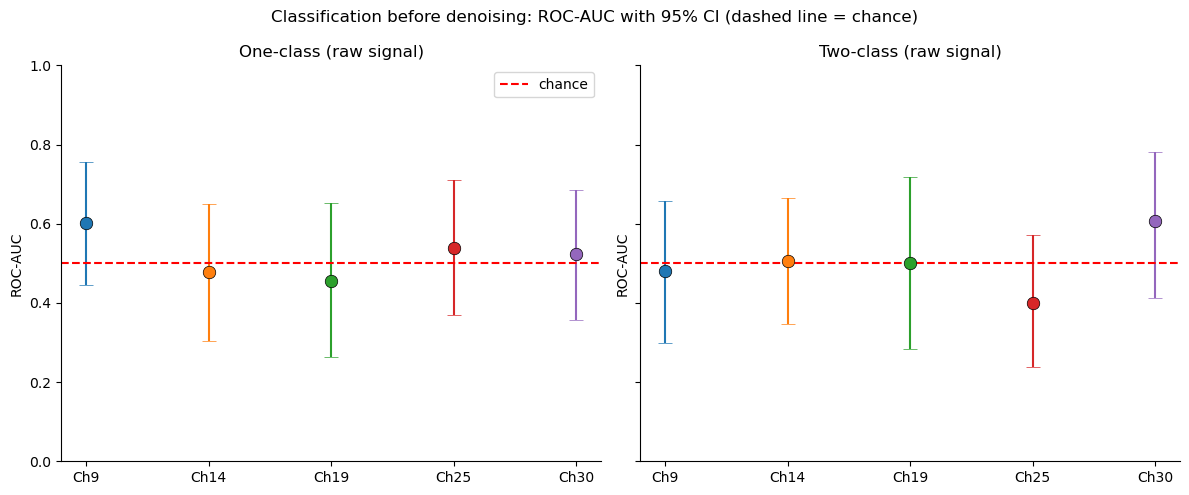

In [107]:
channels = [9, 14, 19, 25, 30]
colours = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']# one colour per channel

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, classifier, title in zip(axes, ["oneclass", "twoclass"], ["One-class", "Two-class"]):
    x = np.arange(len(channels))
    for i, ch in enumerate(channels):
        roc = all_results[ch]["classification"][(classifier, "wavelet", "Full raw")]["roc_auc"]
        point = roc[0]
        lo = roc[0] - roc[1]
        hi = roc[2] - roc[0]
        ax.errorbar(i, point, yerr=[[lo], [hi]], fmt='o', capsize=5,
                    color=colours[i], markersize=9, markeredgecolor='black', markeredgewidth=0.5)
    ax.axhline(0.5, color='red', linestyle='--', label='chance')
    ax.set_xticks(x)
    ax.set_xticklabels([f"Ch{ch}" for ch in channels])
    ax.set_title(f"{title} (raw signal)")
    ax.set_ylim(0, 1)
    ax.set_ylabel("ROC-AUC")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
axes[0].legend()
plt.suptitle("Classification before denoising: ROC-AUC with 95% CI (dashed line = chance)")
plt.tight_layout()
plt.savefig('Classification before denoising: ROC-AUC with 95% CI.png', dpi=300)
plt.show()

In [121]:
#baseline classification metrics all channels both classifiers
channels = [9, 14, 19, 25, 30]
for classifier in ["oneclass", "twoclass"]:
    print(f"\n==={classifier}, baseline (Full raw)==")
    print(f"{'Channel':>8s} {'TP':>4s} {'FP':>4s} {'FN':>4s} {'TN':>4s} {'Precision':>6s} {'Recall':>7s} {'F1':>6s}")
    for ch in channels:
        results = all_results[ch]["classification"][(classifier, "wavelet", "Full raw")]
        print(f"{ch:>8d} {results['tp']:>4d} {results['fp']:>4d} {results['fn']:>4d} {results['tn']:>4d} "
              f"{results['precision']:>6.3f} {results['recall']:>7.3f} {results['f1']:>6.3f}")


===oneclass, baseline (Full raw)==
 Channel   TP   FP   FN   TN Precision  Recall     F1
       9    6   19    6   30  0.240   0.500  0.324
      14   10   28    6   16  0.263   0.625  0.370
      19    6   30    5   22  0.167   0.545  0.255
      25    8   19    6   25  0.296   0.571  0.390
      30    8   28    5   21  0.222   0.615  0.327

===twoclass, baseline (Full raw)==
 Channel   TP   FP   FN   TN Precision  Recall     F1
       9    7   28    5   21  0.200   0.583  0.298
      14   12   33    4   11  0.267   0.750  0.393
      19    6   33    5   19  0.154   0.545  0.240
      25    7   26    7   18  0.212   0.500  0.298
      30    8   22    5   27  0.267   0.615  0.372


# Denoising quality

In [108]:
# denosiing qulaity: MAD and amplitude retention per channel
channels = [9, 14, 19, 25, 30]
print(f"{'Channel':>8s} {'Signal':>9s} {'MAD':>8s} {'Peak-to-peak':>13s} {'Retained':>9s}")
for ch in channels:
    denoising_quality = all_results[ch]["denoising_quality"]
    for name in ["raw", "wavelet", "dense", "conv"]:
        chan_label = str(ch) if name == 'raw' else ''
        print(f"{chan_label:>8} {name:>9s} {denoising_quality[name]['mad']:>8.3f} {denoising_quality[name]['ptp']:>13.2f} {denoising_quality[name]['retained']*100:>8.0f}%")
    print()

 Channel    Signal      MAD  Peak-to-peak  Retained
       9       raw    4.804         22.99      100%
           wavelet    2.267          7.44       32%
             dense    0.491          4.20       18%
              conv    1.096         12.27       53%

      14       raw    4.885         23.82      100%
           wavelet    2.230          7.36       31%
             dense    0.482          4.47       19%
              conv    1.075         13.13       55%

      19       raw    4.958         24.08      100%
           wavelet    2.253          7.62       32%
             dense    0.584          4.81       20%
              conv    1.252         13.67       57%

      25       raw    4.631         21.75      100%
           wavelet    2.308          7.77       36%
             dense    0.498          3.91       18%
              conv    1.045         11.56       53%

      30       raw    4.821         22.75      100%
           wavelet    2.248          7.22       32%
        

# Detection after denoising

In [109]:
#Detection after denoising, denoised signals, all channels
channels = [9, 14, 19, 25, 30]
print(f"{'Channel':>8s} {'Signal':>9s} {'Surv':>5s} {'TP':>4s} {'FP':>4s} {'FN':>4s} {'Recall':>7s} {'F1':>6s} {'FP/TP':>6s}")
for ch in channels:
    det = all_results[ch]["detection"]
    for name in ["raw", "wavelet", "dense", "conv"]:
        chan_label = str(ch) if name == 'raw' else ''
        detection = det[name]
        print(f"{chan_label:>8} {name:>9s} {detection['survivors']:>5d} {detection['tp']:>4d} {detection['fp']:>4d} {detection['fn']:>4d} "
              f"{detection['recall']:>7.3f} {detection['f1']:>6.3f} {detection['fptp']:>6.2f}")
    print()

 Channel    Signal  Surv   TP   FP   FN  Recall     F1  FP/TP
       9       raw    61   12   49   50   0.194  0.195   4.08
           wavelet    59   16   43   46   0.258  0.264   2.69
             dense    60   15   45   47   0.242  0.246   3.00
              conv    65   16   49   46   0.258  0.252   3.06

      14       raw    60   16   44   44   0.267  0.267   2.75
           wavelet    59   16   43   44   0.267  0.269   2.69
             dense    55   10   45   50   0.167  0.174   4.50
              conv    65   15   50   45   0.250  0.240   3.33

      19       raw    63   11   52   50   0.180  0.177   4.73
           wavelet    58   14   44   47   0.230  0.235   3.14
             dense    64    8   56   53   0.131  0.128   7.00
              conv    63   16   47   45   0.262  0.258   2.94

      25       raw    58   14   44   52   0.212  0.226   3.14
           wavelet    52   12   40   54   0.182  0.203   3.33
             dense    61   21   40   45   0.318  0.331   1.90
     

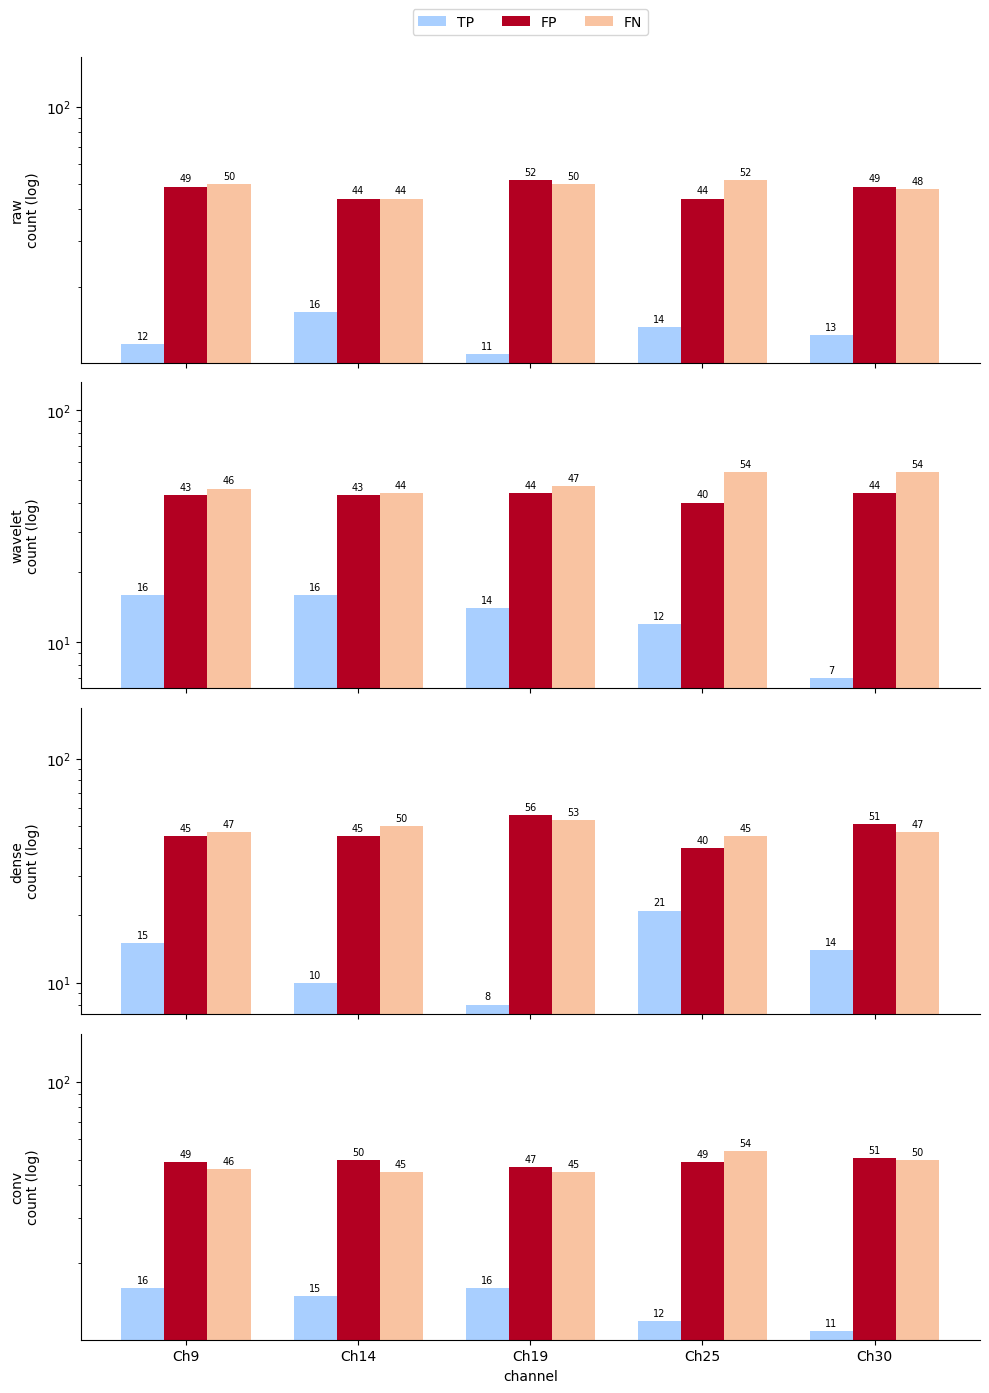

In [110]:
channels = [9, 14, 19, 25, 30]
conditions = ["raw", "wavelet", "dense", "conv"]
colours = {'TP': '#A9CFFF', 'FP': '#B30022', 'FN': '#F9C3A1'}

fig, axes = plt.subplots(len(conditions), 1, figsize=(10, 14), sharex=True)

x = np.arange(len(channels))
width = 0.25

for ax, cond in zip(axes, conditions):
    tp = [all_results[ch]["detection"][cond]["tp"] for ch in channels]
    fp = [all_results[ch]["detection"][cond]["fp"] for ch in channels]
    fn = [all_results[ch]["detection"][cond]["fn"] for ch in channels]
    bars_tp = ax.bar(x - width, tp, width, label='TP', color=colours['TP'])
    bars_fp = ax.bar(x, fp, width, label='FP', color=colours['FP'])
    bars_fn = ax.bar(x + width, fn, width, label='FN', color=colours['FN'])
    for bars in [bars_tp, bars_fp, bars_fn]:
        for bar in bars:
            height = bar.get_height()
            ax.annotate(f'{int(height)}',
                        xy=(bar.get_x() + bar.get_width()/2, height),
                        xytext=(0, 2), textcoords="offset points",
                        ha='center', va='bottom', fontsize=7)
    ax.set_yscale('log')
    ax.set_ylabel(f"{cond}\ncount (log)")
    ax.set_ylim(top=max(fp)*3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


axes[0].legend(loc='lower center', bbox_to_anchor=(0.5, 1.05), ncol=3)
axes[-1].set_xticks(x)
axes[-1].set_xticklabels([f"Ch{ch}" for ch in channels])
axes[-1].set_xlabel("channel")
plt.tight_layout()
plt.savefig('Detection performamce after denoisng.png', dpi=300, bbox_inches='tight')
plt.show()

In [111]:
# FP/TP change relative to raw, per channel and denoiser
channels = [9, 14, 19, 25, 30]
print(f"{'Channel':>8s} {'Denoiser':>9s} {'FP/TP':>7s} {'raw FP/TP':>10s} {'change':>8s}")
for ch in channels:
    det = all_results[ch]["detection"]
    raw_fptp = det["raw"]["fptp"]
    for denoiser in ["wavelet", "dense", "conv"]:
        d_fptp = det[denoiser]["fptp"]
        change = d_fptp - raw_fptp
        arrow = "worse" if change > 0 else "better"
        print(f"{ch:>8d} {denoiser:>9s} {d_fptp:>7.2f} {raw_fptp:>10.2f} {change:>+8.2f} ({arrow})")
    print()

 Channel  Denoiser   FP/TP  raw FP/TP   change
       9   wavelet    2.69       4.08    -1.40 (better)
       9     dense    3.00       4.08    -1.08 (better)
       9      conv    3.06       4.08    -1.02 (better)

      14   wavelet    2.69       2.75    -0.06 (better)
      14     dense    4.50       2.75    +1.75 (worse)
      14      conv    3.33       2.75    +0.58 (worse)

      19   wavelet    3.14       4.73    -1.58 (better)
      19     dense    7.00       4.73    +2.27 (worse)
      19      conv    2.94       4.73    -1.79 (better)

      25   wavelet    3.33       3.14    +0.19 (worse)
      25     dense    1.90       3.14    -1.24 (better)
      25      conv    4.08       3.14    +0.94 (worse)

      30   wavelet    6.29       3.77    +2.52 (worse)
      30     dense    3.64       3.77    -0.13 (better)
      30      conv    4.64       3.77    +0.87 (worse)



# Classification after denoising


In [124]:
#classification after denoising
channels = [9, 14, 19, 25, 30]
for classifier in ["oneclass", "twoclass"]:
    print(f"\n==={classifier}, after denoising (Full denoising)===")
    print(f"{'Channel':>8s} {'Denoiser':9s} {'ROC-AUC [95%CI]':>24s}")
    for ch in channels:
        for denoiser in ["wavelet", "dense", "conv"]:
            roc = all_results[ch]["classification"][(classifier, denoiser, "Full denoised")]["roc_auc"]
            chan = str(ch) if denoiser == "wavelet" else ""
            print(f"{chan:>8} {denoiser:>9s} {roc[0]:.3f} [{roc[1]:.3f}, {roc[2]:.3f}]".rjust(24))


===oneclass, after denoising (Full denoising)===
 Channel Denoiser           ROC-AUC [95%CI]
       9   wavelet 0.541 [0.366, 0.711]
             dense 0.536 [0.370, 0.702]
              conv 0.537 [0.363, 0.703]
      14   wavelet 0.461 [0.305, 0.625]
             dense 0.589 [0.411, 0.764]
              conv 0.517 [0.367, 0.680]
      19   wavelet 0.435 [0.258, 0.612]
             dense 0.438 [0.239, 0.623]
              conv 0.370 [0.215, 0.522]
      25   wavelet 0.552 [0.371, 0.727]
             dense 0.576 [0.421, 0.720]
              conv 0.580 [0.427, 0.735]
      30   wavelet 0.675 [0.409, 0.896]
             dense 0.598 [0.420, 0.758]
              conv 0.649 [0.483, 0.791]

===twoclass, after denoising (Full denoising)===
 Channel Denoiser           ROC-AUC [95%CI]
       9   wavelet 0.509 [0.331, 0.676]
             dense 0.527 [0.351, 0.704]
              conv 0.509 [0.356, 0.672]
      14   wavelet 0.491 [0.308, 0.673]
             dense 0.613 [0.387, 0.822]
            

In [127]:
#classification metrics after denoising
channel = [9, 14, 19, 25, 30]
for classifier in ["oneclass", "twoclass"]:
    print(f"\n==={classifier} metrics, after denoising (Full denoised)==")
    print(f"{'Channel':>8s} {'TP':>4s} {'FP':>4s} {'FN':>4s} {'TN':>4s} {'Precision':>6s} {'Recall':>7s} {'F1':>6s}")
    for ch in channels:
        for denoiser in ["wavelet", "dense", "conv"]:
            results = all_results[ch]["classification"][(classifier, denoiser,  "Full denoised")]
            print(f"{ch:>8d} {results['tp']:>4d} {results['fp']:>4d} {results['fn']:>4d} {results['tn']:>4d} "
                  f"{results['precision']:>6.3f} {results['recall']:>7.3f} {results['f1']:>6.3f}")


===oneclass metrics, after denoising (Full denoised)==
 Channel   TP   FP   FN   TN Precision  Recall     F1
       9   13   36    3    7  0.265   0.812  0.400
       9   11   30    4   15  0.268   0.733  0.393
       9   11   30    5   19  0.268   0.688  0.386
      14   14   37    2    6  0.275   0.875  0.418
      14    8   29    2   16  0.216   0.800  0.340
      14    8   28    7   22  0.222   0.533  0.314
      19   11   40    3    4  0.216   0.786  0.338
      19    6   40    2   16  0.130   0.750  0.222
      19    8   33    9   13  0.195   0.471  0.276
      25   11   31    1    9  0.262   0.917  0.407
      25   20   33    1    7  0.377   0.952  0.541
      25   12   38    0   11  0.240   1.000  0.387
      30    6   37    1    7  0.140   0.857  0.240
      30   10   35    4   16  0.222   0.714  0.339
      30    9   28    2   23  0.243   0.818  0.375

===twoclass metrics, after denoising (Full denoised)==
 Channel   TP   FP   FN   TN Precision  Recall     F1
       9    9  

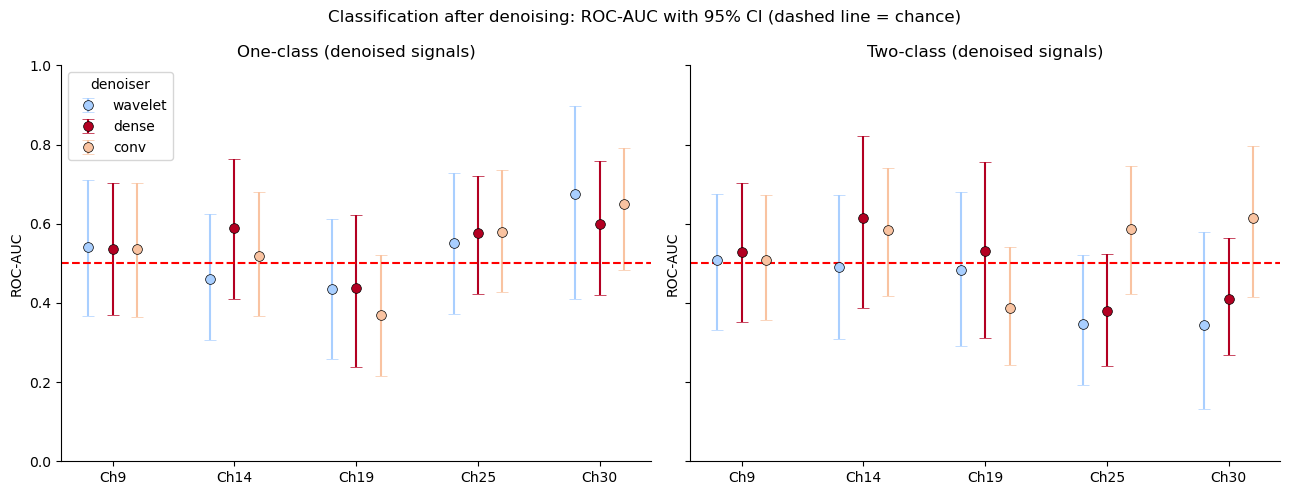

In [132]:
#same plot
channels = [9, 14, 19, 25, 30]
denoisers = ["wavelet", "dense", "conv"]
denoiser_colours = {'wavelet': '#A9CFFF', 'dense': '#B30022', 'conv': '#F9C3A1'}
offsets = {'wavelet': -0.2, 'dense': 0.0, 'conv': 0.2}

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, classifier, title in zip(axes, ["oneclass", "twoclass"], ["One-class", "Two-class"]):
    for i, ch in enumerate(channels):
        for denoiser in denoisers:
            roc = all_results[ch]["classification"][(classifier, denoiser, "Full denoised")]["roc_auc"]
            ax.errorbar(i + offsets[denoiser], roc[0],
                        yerr=[[roc[0]-roc[1]], [roc[2]-roc[0]]], fmt='o', capsize=4,
                        color=denoiser_colours[denoiser], markersize=7,
                        markeredgecolor='black', markeredgewidth=0.5,
                        label=denoiser if i == 0 else "")
    ax.axhline(0.5, color='red', linestyle='--')
    ax.set_xticks(range(len(channels)))
    ax.set_xticklabels([f"Ch{ch}" for ch in channels])
    ax.set_title(f"{title} (denoised signals)")
    ax.set_ylim(0, 1)
    ax.set_ylabel("ROC-AUC")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
axes[0].legend(title="denoiser")
plt.suptitle("Classification after denoising: ROC-AUC with 95% CI (dashed line = chance)")
plt.tight_layout()
plt.savefig('classification after denoising.png', dpi=300, bbox_inches='tight')
plt.show()